## 1. Setup & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
NAVY  = '#1C2B4A'
GOLD  = '#C9A84C'
TEAL  = '#0D9488'
RED   = '#E24B4A'
LIGHT = '#F4F6F9'
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LIGHT,
    'axes.edgecolor':   '#CBD5E0',
    'axes.labelcolor':  NAVY,
    'axes.titlecolor':  NAVY,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'xtick.color':      '#4A5568',
    'ytick.color':      '#4A5568',
    'grid.color':       'white',
    'grid.linewidth':   1.0,
    'font.family':      'sans-serif',
})

# ── Load ───────────────────────────────────────────────────────────────────

DATA = Path('../data/processed')   

tm = pd.read_csv(DATA / 'training_matrix.csv',    parse_dates=['date'])
pm = pd.read_csv(DATA / 'prediction_matrix.csv',    parse_dates=['date'])

# Encode categoricals for correlation
DOW_MAP    = {'Mon':0,'Tue':1,'Wed':2,'Thu':3,'Fri':4,'Sat':5,'Sun':6}
SEASON_MAP = {'low':0,'shoulder':1,'high':2}
tm_enc = tm.copy()
tm_enc['dow']    = tm_enc['dow'].map(DOW_MAP)
tm_enc['season'] = tm_enc['season'].map(SEASON_MAP)

FEATURES = ['month','dow','is_weekend','is_high_season','cs_occ','cs_adr',
            'b_occ','b_adr','floor_price','is_bank_holiday',
            'is_cultural_holiday','is_local_event','season']

print(f"Training matrix : {tm.shape}  |  {tm.date.min().date()} → {tm.date.max().date()}")
print(f"Prediction matrix: {pm.shape}  |  {pm.date.min().date()} → {pm.date.max().date()}")
print(f"\nTarget (occ_rate) — mean: {tm.occ_rate.mean():.1%}  std: {tm.occ_rate.std():.1%}  "
      f"min: {tm.occ_rate.min():.1%}  max: {tm.occ_rate.max():.1%}")


Training matrix : (638, 34)  |  2024-04-01 → 2025-12-30
Prediction matrix: (307, 32)  |  2026-02-28 → 2026-12-31

Target (occ_rate) — mean: 66.3%  std: 28.0%  min: 0.0%  max: 100.0%


## 2. Target Variable Distribution
`occ_rate` is what the model predicts. Understanding its shape is the first thing to check.

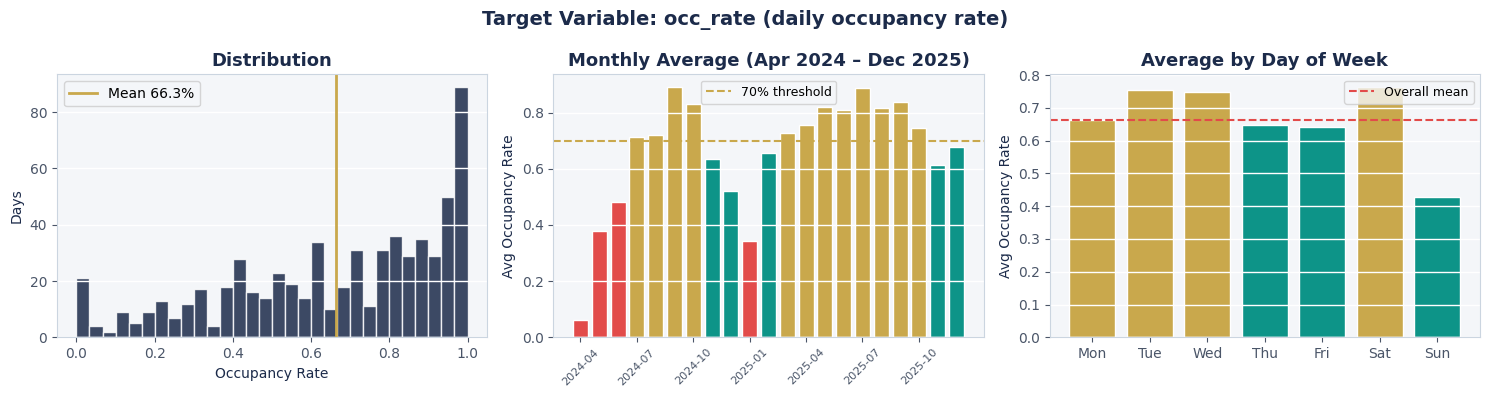

Insight: Bimodal distribution — occupancy clusters at very low (<20%) and very high (>80%).
Tuesday and Wednesday outperform — strong corporate midweek segment.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Target Variable: occ_rate (daily occupancy rate)', fontsize=14, color=NAVY, fontweight='bold')

# Histogram
ax = axes[0]
ax.hist(tm['occ_rate'].dropna(), bins=30, color=NAVY, alpha=0.85, edgecolor='white')
ax.axvline(tm['occ_rate'].mean(), color=GOLD, linewidth=2, label=f"Mean {tm['occ_rate'].mean():.1%}")
ax.set_xlabel('Occupancy Rate')
ax.set_ylabel('Days')
ax.set_title('Distribution')
ax.legend(fontsize=10)
ax.grid(True, axis='y')

# Monthly avg
ax = axes[1]
monthly = tm.groupby(tm['date'].dt.to_period('M'))['occ_rate'].mean()
colors  = [GOLD if v >= 0.70 else TEAL if v >= 0.50 else RED for v in monthly]
ax.bar(range(len(monthly)), monthly.values, color=colors, edgecolor='white')
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels([str(p) for p in monthly.index[::3]], rotation=45, fontsize=8)
ax.axhline(0.70, color=GOLD, linewidth=1.5, linestyle='--', label='70% threshold')
ax.set_ylabel('Avg Occupancy Rate')
ax.set_title('Monthly Average (Apr 2024 – Dec 2025)')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# By day of week
ax = axes[2]
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg   = tm.groupby('dow')['occ_rate'].mean().reindex(dow_order)
colors_d  = [GOLD if v >= dow_avg.mean() else TEAL for v in dow_avg]
ax.bar(dow_order, dow_avg.values, color=colors_d, edgecolor='white')
ax.axhline(dow_avg.mean(), color=RED, linewidth=1.5, linestyle='--', label='Overall mean')
ax.set_ylabel('Avg Occupancy Rate')
ax.set_title('Average by Day of Week')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_matrix_01_target.png', dpi=120, bbox_inches='tight')
plt.show()
print("Insight: Bimodal distribution — occupancy clusters at very low (<20%) and very high (>80%).")
print("Tuesday and Wednesday outperform — strong corporate midweek segment.")


## 3. Feature Correlations with Target
Pearson correlation between each feature and `occ_rate`. Tells us which features the model should rely on most.

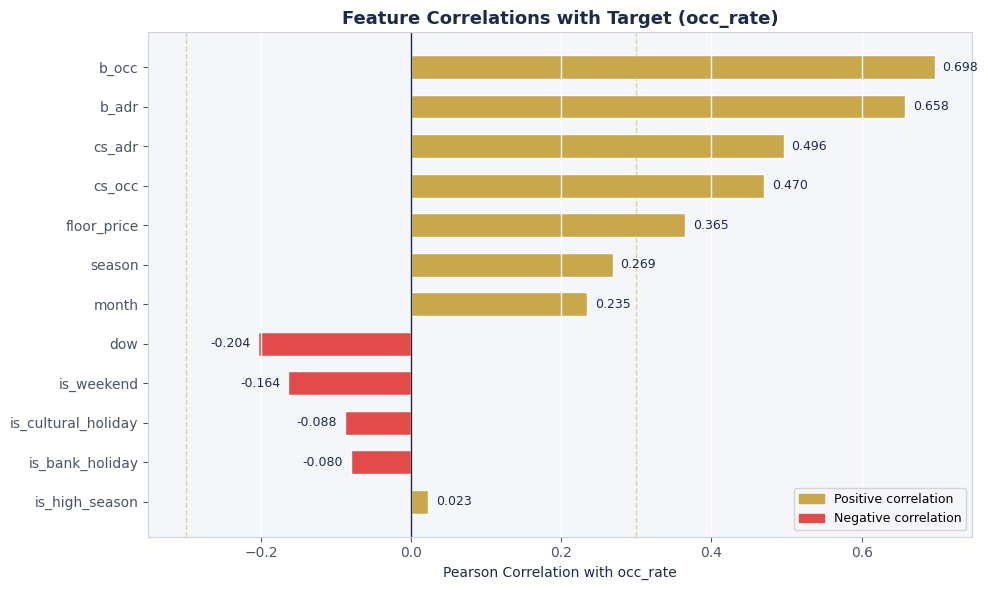


Top correlations:
b_occ                  0.698
b_adr                  0.658
cs_adr                 0.496
cs_occ                 0.470
floor_price            0.365
season                 0.269
month                  0.235
dow                   -0.204
is_weekend            -0.164
is_cultural_holiday   -0.088
is_bank_holiday       -0.080
is_high_season         0.023

Insight: b_occ (0.70) and b_adr (0.66) are strongest predictors.
Note: b_occ/b_adr are missing for 274 rows (2024 data had no budget file).


In [4]:
corr = (tm_enc[FEATURES + ['occ_rate']]
        .corr()['occ_rate']
        .drop('occ_rate')
        .dropna()
        .sort_values(key=abs, ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors  = [GOLD if v > 0 else RED for v in corr.values]
bars    = ax.barh(corr.index, corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color=NAVY, linewidth=1)
ax.axvline(0.3,  color=GOLD, linewidth=1, linestyle='--', alpha=0.5, label='±0.3 threshold')
ax.axvline(-0.3, color=GOLD, linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Pearson Correlation with occ_rate')
ax.set_title('Feature Correlations with Target (occ_rate)')
ax.legend(fontsize=9)
ax.grid(True, axis='x')

# Value labels
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, color=NAVY)

gold_patch = mpatches.Patch(color=GOLD, label='Positive correlation')
red_patch  = mpatches.Patch(color=RED,  label='Negative correlation')
ax.legend(handles=[gold_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig('eda_matrix_02_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop correlations:")
print(corr.sort_values(key=abs, ascending=False).round(3).to_string())
print("\nInsight: b_occ (0.70) and b_adr (0.66) are strongest predictors.")
print("Note: b_occ/b_adr are missing for 274 rows (2024 data had no budget file).")


## 4. Missing Data Analysis
Missing values affect model training. Knowing where they are explains some model decisions.

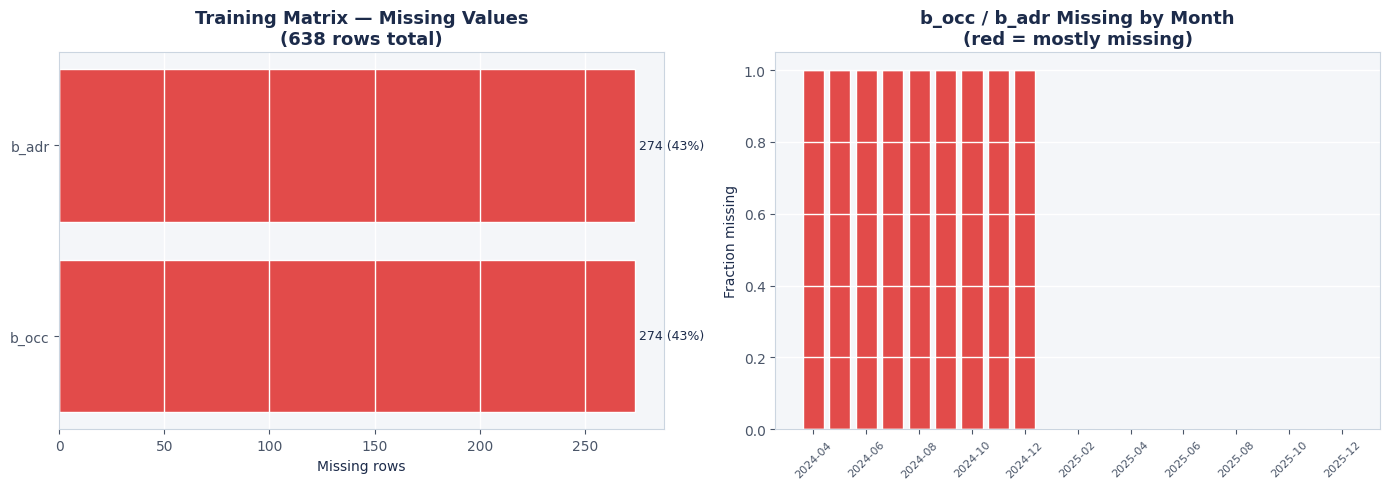

Insight: b_occ and b_adr are missing for all of 2024 (budget file only covered 2025/2026).
Model fills these with 0 during training — reduces their predictive power for 2024 rows.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training matrix missing
ax = axes[0]
miss_tm = tm[FEATURES + ['occ_rate']].isna().sum()
miss_tm = miss_tm[miss_tm > 0]
if len(miss_tm) > 0:
    colors_m = [RED if v > 100 else GOLD for v in miss_tm.values]
    ax.barh(miss_tm.index, miss_tm.values, color=colors_m, edgecolor='white')
    for i, v in enumerate(miss_tm.values):
        ax.text(v + 2, i, f'{v} ({v/len(tm):.0%})', va='center', fontsize=9, color=NAVY)
    ax.set_xlabel('Missing rows')
    ax.set_title(f'Training Matrix — Missing Values\n(638 rows total)')
    ax.grid(True, axis='x')
else:
    ax.text(0.5, 0.5, 'No missing values\nin model features',
            ha='center', va='center', transform=ax.transAxes, fontsize=14, color=TEAL)
    ax.set_title('Training Matrix — Missing Values')

# When are b_occ/b_adr missing?
ax = axes[1]
tm['b_occ_missing'] = tm['b_occ'].isna().astype(int)
monthly_miss = tm.groupby(tm['date'].dt.to_period('M'))['b_occ_missing'].mean()
colors_m2 = [RED if v > 0.5 else TEAL for v in monthly_miss.values]
ax.bar(range(len(monthly_miss)), monthly_miss.values, color=colors_m2, edgecolor='white')
ax.set_xticks(range(0, len(monthly_miss), 2))
ax.set_xticklabels([str(p) for p in monthly_miss.index[::2]], rotation=45, fontsize=8)
ax.set_ylabel('Fraction missing')
ax.set_title('b_occ / b_adr Missing by Month\n(red = mostly missing)')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_matrix_03_missing.png', dpi=120, bbox_inches='tight')
plt.show()
print("Insight: b_occ and b_adr are missing for all of 2024 (budget file only covered 2025/2026).")
print("Model fills these with 0 during training — reduces their predictive power for 2024 rows.")


## 5. Seasonality Patterns
Month × Day-of-week heatmap shows which date combinations are busiest.

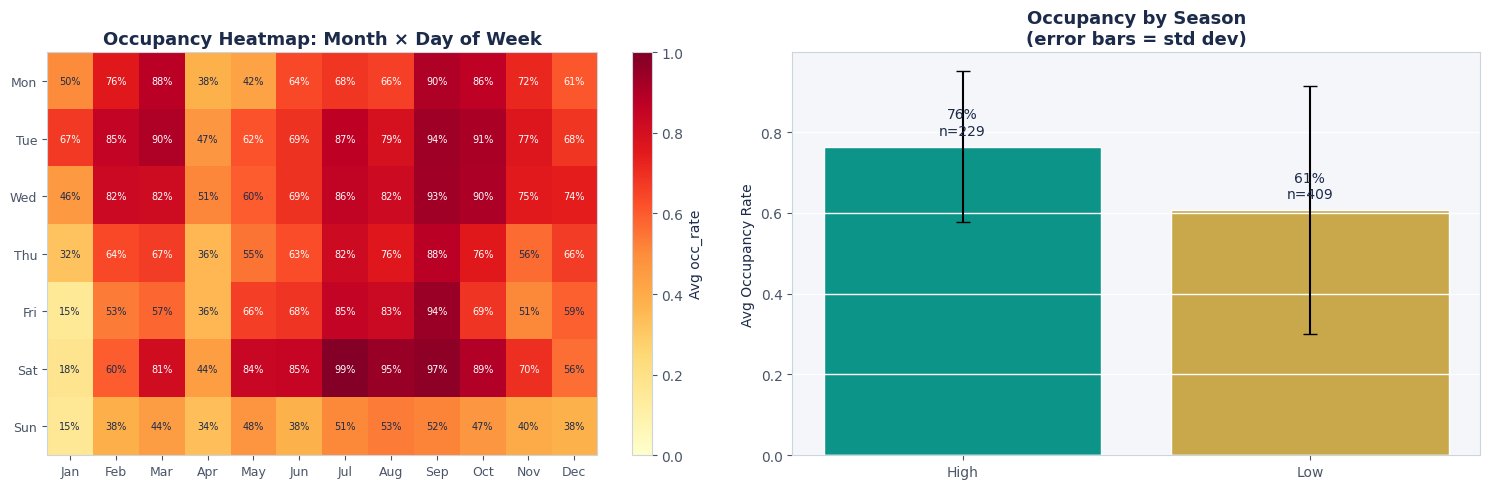

Insight: July/Aug are peak months, Sunday is consistently weakest day.
High season months average significantly higher occupancy than low season.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Month × DOW heatmap
ax = axes[0]
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = tm.pivot_table(values='occ_rate', index='dow', columns='month', aggfunc='mean')
pivot = pivot.reindex(dow_order)
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(dow_order, fontsize=9)
ax.set_title('Occupancy Heatmap: Month × Day of Week')
plt.colorbar(im, ax=ax, label='Avg occ_rate')
# Annotate cells
for i in range(7):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=7, color='white' if val > 0.6 else NAVY)

# Season distribution
ax = axes[1]
season_map_rev = {0:'Low', 1:'Shoulder', 2:'High'}
tm_s = tm.copy()
tm_s['season_label'] = tm_s['season'].map({'low':'Low','shoulder':'Shoulder','high':'High'})
season_occ = tm_s.groupby('season_label')['occ_rate'].agg(['mean','std','count'])
colors_s = [TEAL, GOLD, RED]
bars = ax.bar(season_occ.index, season_occ['mean'], 
              yerr=season_occ['std'], color=[TEAL,GOLD,RED],
              edgecolor='white', capsize=5, error_kw={'color': NAVY})
ax.set_ylabel('Avg Occupancy Rate')
ax.set_title('Occupancy by Season\n(error bars = std dev)')
ax.grid(True, axis='y')
for bar, (idx, row) in zip(bars, season_occ.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{row['mean']:.0%}\nn={int(row['count'])}", ha='center', fontsize=10, color=NAVY)

plt.tight_layout()
plt.savefig('eda_matrix_04_seasonality.png', dpi=120, bbox_inches='tight')
plt.show()
print("Insight: July/Aug are peak months, Sunday is consistently weakest day.")
print("High season months average significantly higher occupancy than low season.")


## 6. Feature Distributions (Training)
Distribution of numeric features used in the model.

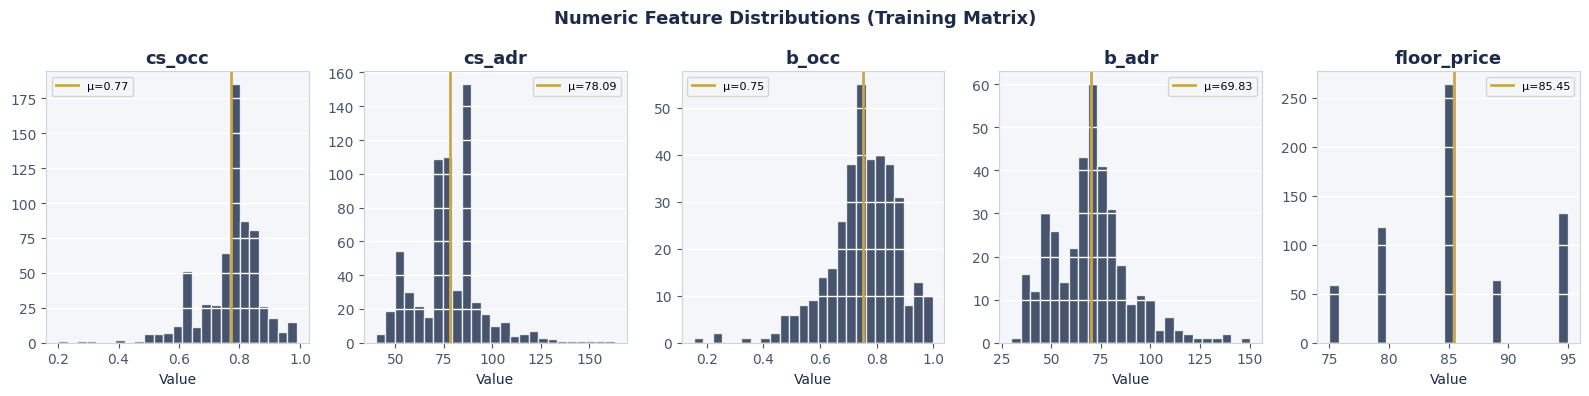

Summary statistics for numeric features:
       cs_occ  cs_adr   b_occ   b_adr  floor_price
count  638.00  638.00  364.00  364.00       638.00
mean     0.77   78.09    0.75   69.83        85.45
std      0.10   17.21    0.12   19.41         6.18
min      0.20   40.00    0.15   29.90        75.00
25%      0.75   71.15    0.69   55.85        79.00
50%      0.79   77.25    0.75   69.81        85.00
75%      0.82   88.24    0.83   79.35        89.00
max      0.99  163.02    1.00  150.36        95.00


In [7]:
numeric_feats = ['cs_occ', 'cs_adr', 'b_occ', 'b_adr', 'floor_price']
fig, axes = plt.subplots(1, len(numeric_feats), figsize=(16, 4))
fig.suptitle('Numeric Feature Distributions (Training Matrix)', fontsize=13, color=NAVY, fontweight='bold')

for ax, feat in zip(axes, numeric_feats):
    data = tm[feat].dropna()
    ax.hist(data, bins=25, color=NAVY, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color=GOLD, linewidth=2, label=f'μ={data.mean():.2f}')
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_matrix_05_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary stats
print("Summary statistics for numeric features:")
print(tm[numeric_feats].describe().round(2).to_string())


## 7. Distribution Shift: Training vs Prediction
Critical check: do 2026 feature values look similar to training data?  
If they don't, the model is extrapolating — predictions become less reliable.

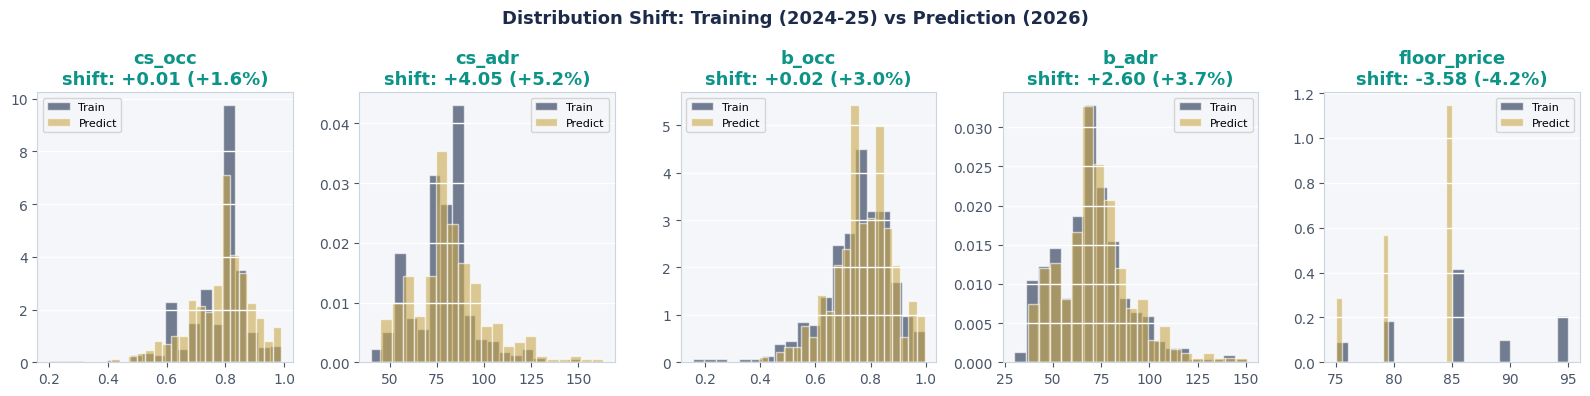

Distribution shift summary:
Feature                  Train mean    Pred mean      Shift   Shift%
--------------------------------------------------------------------
cs_occ                        0.772        0.785     +0.012    +1.6%  ✅
cs_adr                       78.095       82.146     +4.051    +5.2%  ✅
b_occ                         0.751        0.774     +0.023    +3.0%  ✅
b_adr                        69.830       72.434     +2.604    +3.7%  ✅
floor_price                  85.451       81.866     -3.585    -4.2%  ✅

Insight: cs_adr shifts +4.05 (competitors raised rates in 2026 vs training period).
floor_price shifts -3.59 (lower floor rates set for 2026).
No shift exceeds 10% — model should generalise reasonably to 2026.


In [8]:
common = ['cs_occ', 'cs_adr', 'b_occ', 'b_adr', 'floor_price']

fig, axes = plt.subplots(1, len(common), figsize=(16, 4))
fig.suptitle('Distribution Shift: Training (2024-25) vs Prediction (2026)', 
             fontsize=13, color=NAVY, fontweight='bold')

for ax, feat in zip(axes, common):
    t_data = tm[feat].dropna()
    p_data = pm[feat].dropna()
    
    ax.hist(t_data, bins=20, color=NAVY, alpha=0.6, label='Train', edgecolor='white', density=True)
    ax.hist(p_data, bins=20, color=GOLD, alpha=0.6, label='Predict', edgecolor='white', density=True)
    
    shift = p_data.mean() - t_data.mean()
    shift_pct = (shift / t_data.mean() * 100) if t_data.mean() != 0 else 0
    color = RED if abs(shift_pct) > 10 else TEAL
    
    ax.set_title(f'{feat}\nshift: {shift:+.2f} ({shift_pct:+.1f}%)', color=color)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_matrix_06_shift.png', dpi=120, bbox_inches='tight')
plt.show()

print("Distribution shift summary:")
print(f"{'Feature':<22} {'Train mean':>12} {'Pred mean':>12} {'Shift':>10} {'Shift%':>8}")
print("-" * 68)
for feat in common:
    tm_m = tm[feat].mean()
    pm_m = pm[feat].mean()
    shift = pm_m - tm_m
    pct   = shift / tm_m * 100 if tm_m != 0 else 0
    flag  = ' ⚠️' if abs(pct) > 10 else '  ✅'
    print(f"{feat:<22} {tm_m:>12.3f} {pm_m:>12.3f} {shift:>+10.3f} {pct:>+7.1f}%{flag}")

print("\nInsight: cs_adr shifts +4.05 (competitors raised rates in 2026 vs training period).")
print("floor_price shifts -3.59 (lower floor rates set for 2026).")
print("No shift exceeds 10% — model should generalise reasonably to 2026.")


## 8. Key Findings

### Target Variable
- Mean occupancy **66.3%** across 638 training days (Apr 2024 – Dec 2025)
- High std (28%) — hotel has very variable demand, making prediction non-trivial
- Bimodal distribution: many very low days (hotel opening, Jan) and many very high days (summer)

### Feature Quality
| Feature | Correlation | Notes |
|---|---|---|
| `b_occ` | **+0.70** | Strongest predictor — but missing 274 rows (2024) |
| `b_adr` | **+0.66** | Second strongest — same missing issue |
| `cs_adr` | +0.50 | Competitor ADR is a reliable signal |
| `cs_occ` | +0.47 | Competitor occupancy tracks well |
| `floor_price` | +0.37 | FIT rate correlates with demand season |
| `is_bank_holiday` | -0.08 | Surprisingly weak — bank holidays don't drive Hickstead |
| `is_local_event` | NaN | All zeros in training — no local events recorded |

### Missing Data
- `b_occ` / `b_adr` missing for all of 2024 (274 rows) — budget file only covered 2025/2026
- Model compensates by relying more on `cs_occ`, `cs_adr`, calendar features for 2024 rows

### Distribution Shift (Train → 2026)
- All features within ±10% shift — model generalises safely to 2026
- `cs_adr` +5.2% (competitors raised rates), `floor_price` -4.2% (lower floor set)
- No severe extrapolation risk detected

### Seasonality
- **July peak** (+27pp above average), **January trough** (-49pp)
- **Tuesday/Wednesday** are the strongest weekdays — corporate segment
- **Sunday** is consistently weakest — leisure guests check out, don't check in

### Model Implications
- BOB features (`bob_occ`, `pickup_1d`, `pickup_7d`) exist in prediction matrix but NOT in training — this is the main reason predictions skew optimistic vs reality
- Recommended next step: add `occ_lag_7`, `occ_lag_28`, `occ_roll7` to FEATURES list in Script 07
